1. Install Depedensi

In [1]:
import json
import shutil
import random
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATASET_ROOT = Path(r"/kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets")
YOLO_OUT = Path(r"/kaggle/working/YOLO_Dataset")

FILE_ANOTASI_COCO = "_annotations.coco.json"

SPLITS = ["train", "valid", "test"]

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
for split in SPLITS:

    split_dir = DATASET_ROOT / split
    json_path = split_dir / FILE_ANOTASI_COCO

    print(f"\n[{split}]")
    print("Folder :", split_dir)
    print("JSON   :", json_path)
    print("JSON exists :", json_path.exists())


[train]
Folder : /kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets/train
JSON   : /kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets/train/_annotations.coco.json
JSON exists : True

[valid]
Folder : /kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets/valid
JSON   : /kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets/valid/_annotations.coco.json
JSON exists : True

[test]
Folder : /kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets/test
JSON   : /kaggle/input/datasets/ihsanaliandi/dataset-lomba/Telepati 8.0 Datasets/test/_annotations.coco.json
JSON exists : True


In [4]:
def cek_coco(json_path):

    data = json.loads(
        json_path.read_text(encoding="utf-8")
    )

    images = {
        img["id"]: img
        for img in data["images"]
    }

    categories = {
        cat["id"]: cat["name"]
        for cat in data["categories"]
    }

    image_ids = set(images.keys())

    Anotasi_per_image = {}

    for anotasi in data["annotations"]:

        Anotasi_per_image.setdefault(
            anotasi["image_id"], []
        ).append(anotasi)

    orphan_anotasi = [
        anotasi
        for anotasi in data["annotations"]
        if anotasi["image_id"] not in image_ids
    ]

    gambar_tanpa_anotasi = [
        gambar
        for id_gambar, gambar in images.items()
        if id_gambar not in Anotasi_per_image
    ]

    invalid_bbox = []

    for anotasi in data["annotations"]:

        if anotasi["image_id"] not in images:
            continue

        img = images[anotasi["image_id"]]

        W = img["width"]
        H = img["height"]

        bbox = anotasi.get("bbox")

        if (
            bbox is None
            or len(bbox) != 4
            or bbox[2] <= 0
            or bbox[3] <= 0
        ):
            invalid_bbox.append(anotasi)
            continue

        x, y, w, h = bbox

        if (
            x < 0
            or y < 0
            or x + w > W
            or y + h > H
        ):
            invalid_bbox.append(anotasi)

    class_counts = Counter()

    for anotasi in data["annotations"]:

        nama = categories.get(
            anotasi["category_id"],
            "UNKNOWN"
        )

        class_counts[nama] += 1

    print(f"Gambar              : {len(images)}")
    print(f"Anotasi            : {len(data['annotations'])}")
    print(f"Anotasi yang Orphan      : {len(orphan_anotasi)}")
    print(f"Gambar tanpa anotasi : {len(gambar_tanpa_anotasi)}")
    print(f"Bbox invalid/outside    : {len(invalid_bbox)}")

    print("Distribusi kategori:")

    for name, count in class_counts.most_common():
        print(f"{name:<35}: {count}")

    return data

In [5]:
data_coco= {}

for split in SPLITS:

    json_path = DATASET_ROOT / split / FILE_ANOTASI_COCO
    print(f"AUDIT {split.upper()}")

    data_coco[split] = cek_coco(json_path)

AUDIT TRAIN
Gambar              : 10133
Anotasi            : 20163
Anotasi yang Orphan      : 0
Gambar tanpa anotasi : 59
Bbox invalid/outside    : 427
Distribusi kategori:
BrownSpot                          : 3388
Blast                              : 3033
Rice-Tungro                        : 2540
Sheath Blight                      : 1762
Brown spot                         : 1622
Leaf Scald                         : 1224
False-Smut                         : 852
Infected Blast                     : 832
Leaf-roller                        : 812
Healthy Rice Leaf                  : 717
Healthy Rice beads                 : 699
Healthy                            : 686
Bacterial panicle Blight           : 528
Bacterial leaf blight              : 476
Leaf blast                         : 284
healthy                            : 272
Narrow brown                       : 222
Leaf scald                         : 214
AUDIT VALID
Gambar              : 2106
Anotasi            : 4888
Anotasi yang Orpha

In [6]:
KELAS_CANONICAL = [
    "bacterial_leaf_blight",
    "bacterial_panicle_blight",
    "blast",
    "brown_spot",
    "false_smut",
    "healthy",
    "leaf_scald",
    "leaf_roller",
    "narrow_brown",
    "tungro",
    "sheath_blight",
]

CLASS_TO_ID = {
    name: i
    for i, name in enumerate(KELAS_CANONICAL)
}

In [7]:
CLASS_MAPPING = {

    "Bacterial leaf blight":
        "bacterial_leaf_blight",

    "Bacterial panicle Blight":
        "bacterial_panicle_blight",

    "Blast":
        "blast",

    "Leaf blast":
        "blast",

    "Infected Blast":
        "blast",

    "Brown spot":
        "brown_spot",

    "BrownSpot":
        "brown_spot",

    "False-Smut":
        "false_smut",

    "Healthy Rice Leaf":
        "healthy",
    
    "Healthy Rice beads":
        "healthy",        

    "Healthy":
        "healthy",
    
    "healthy":
        "healthy",

    "Leaf-roller":
        "leaf_roller",

    "Leaf Scald":
        "leaf_scald",

    "Leaf scald":
        "leaf_scald",

    "Narrow brown":
        "narrow_brown",

    "Sheath Blight":
        "sheath_blight",

    "Rice-Tungro":
        "tungro",
}

In [8]:
def ambil_id_canonical(raw_name):
    name = raw_name.strip()
    nama_canonical = CLASS_MAPPING.get(name)
    if nama_canonical is None:
        return None
    return CLASS_TO_ID[nama_canonical]

In [9]:
def bbox_dari_segmentasi(segmentation):

    if not segmentation:
        return None

    if not isinstance(segmentation, list):
        return None

    points = []

    for polygon in segmentation:

        if not isinstance(polygon, list):
            continue

        if len(polygon) < 6:
            continue

        xs = polygon[0::2]
        ys = polygon[1::2]

        points.extend(zip(xs, ys))

    if not points:
        return None

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    xmin = min(xs)
    ymin = min(ys)
    xmax = max(xs)
    ymax = max(ys)

    w = xmax - xmin
    h = ymax - ymin

    if w <= 0 or h <= 0:
        return None

    return [xmin, ymin, w, h]

In [10]:
def benerin_bbox(bbox, lebar_gambar, tinggi_gambar):

    if bbox is None or len(bbox) != 4:
        return None, False

    x, y, w, h = bbox

    if w <= 0 or h <= 0:
        return None, False

    x1 = x
    y1 = y
    x2 = x + w
    y2 = y + h

    new_x1 = max(0, min(x1, lebar_gambar))
    new_y1 = max(0, min(y1, tinggi_gambar))

    new_x2 = max(0, min(x2, lebar_gambar))
    new_y2 = max(0, min(y2, tinggi_gambar))

    new_w = new_x2 - new_x1
    new_h = new_y2 - new_y1

    if new_w <= 0 or new_h <= 0:
        return None, False

    clipped = (
        new_x1 != x1
        or new_y1 != y1
        or new_x2 != x2
        or new_y2 != y2
    )

    return [
        new_x1,
        new_y1,
        new_w,
        new_h
    ], clipped

In [11]:
def konversi_split(
    json_path,
    dir_gambar,
    dir_output,
    split
):

    data = json.loads(
        json_path.read_text(
            encoding="utf-8"
        )
    )

    categories = {
        category["id"]: category["name"]
        for category in data["categories"]
    }

    images = {
        img["id"]: img
        for img in data["images"]
    }

    anotasi_per_image = {}

    for anotasi in data["annotations"]:

        anotasi_per_image.setdefault(
            anotasi["image_id"],
            []
        ).append(anotasi)

    # OUTPUT

    img_output_dir = (
        dir_output /
        split /
        "images"
    )

    label_output_dir = (
        dir_output /
        split /
        "labels"
    )

    img_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    label_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    stats = Counter()

    # PROCESS IMAGE

    for id_gambar, gambar in images.items():

        file_name = gambar["file_name"]

        W = gambar["width"]
        H = gambar["height"]

        src_image = dir_gambar / file_name

        if not src_image.exists():

            stats["images_missing"] += 1
            continue

        annotations = anotasi_per_image.get(
            id_gambar,
            []
        )
        if not annotations:

            stats["images_without_annotation"] += 1
            continue

        lines = []

        # PROCESS ANNOTATIONS
        for anotasi in annotations:

            # CLASS MAPPING

            raw_name = categories.get(
                anotasi["category_id"]
            )

            if raw_name is None:
                continue

            class_id = ambil_id_canonical(
                raw_name
            )

            # Bukan 11 canonical
            if class_id is None:

                stats[
                    "annotations_unmapped"
                ] += 1

                continue

            # BBOX
            bbox = anotasi.get("bbox")

            bbox_bener = None
            clipped = False

            if bbox is not None:

                bbox_bener, clipped = benerin_bbox(
                    bbox,
                    W,
                    H
                )


            # SEGMENTATION FALLBACK

            if bbox_bener is None:

                bbox_seg = bbox_dari_segmentasi(
                    anotasi.get("segmentation")
                )

                if bbox_seg is not None:

                    bbox_bener, clipped = benerin_bbox(
                        bbox_seg,
                        W,
                        H
                    )

                    if bbox_bener is not None:

                        stats[
                            "boxes_from_segmentation"
                        ] += 1


            # INVALID
            if bbox_bener is None:

                stats[
                    "boxes_dropped_invalid"
                ] += 1

                continue
            # CLIPPED

            if clipped:

                stats[
                    "boxes_clipped"
                ] += 1


            # COCO → YOLO
            x, y, w, h = bbox_bener

            x_center = (
                x + w / 2
            ) / W

            y_center = (
                y + h / 2
            ) / H

            w_norm = w / W
            h_norm = h / H

            lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{w_norm:.6f} "
                f"{h_norm:.6f}"
            )

            stats["boxes_kept"] += 1

        # TIDAK ADA LABEL VALID
        if not lines:

            stats[
                "images_without_valid_labels"
            ] += 1
            continue

        # COPY IMAGE
        Tujuan_gambar = (
            img_output_dir /
            file_name
        )

        Tujuan_gambar.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            src_image,
            Tujuan_gambar
        )

        # WRITE LABEL
        label_path = (
            label_output_dir /
            Path(file_name).with_suffix(".txt")
        )

        label_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        label_path.write_text(
            "\n".join(lines),
            encoding="utf-8"
        )

        stats["images_written"] += 1

    # REPORT
    print(f"\n[{split}]")
    print(f"Total gambar              : {len(images)}")
    print(
        f"Gambar ditulis           : "
        f"{stats['images_written']}"
    )
    print(
        f"Gambar tanpa anotasi  : "
        f"{stats['images_without_annotation']}"
    )
    print(
        f"Gambar tanpa label valid : "
        f"{stats['images_without_valid_labels']}"
    )
    print(
        f"Gambar Hilang           : "
        f"{stats['images_missing']}"
    )
    print(
        f"Box Dipertahankan              : "
        f"{stats['boxes_kept']}"
    )
    print(
        f"Box di clip           : "
        f"{stats['boxes_clipped']}"
    )
    print(
        f"Box dari segmentasi : "
        f"{stats['boxes_from_segmentation']}"
    )
    print(
        f"Box invalid dibuang    : "
        f"{stats['boxes_dropped_invalid']}"
    )
    print(
        f"Anotasi tidak termapping   : "
        f"{stats['annotations_unmapped']}"
    )

    return stats

In [12]:
Semua_statistik = {}

for split in SPLITS:

    json_path = (
        DATASET_ROOT /
        split /
        FILE_ANOTASI_COCO
    )

    dir_banyak_gambar = (
        DATASET_ROOT /
        split
    )

    if not json_path.exists():

        print(
            f"\n[{split}] "
            f"JSON tidak ditemukan: "
            f"{json_path}"
        )

        continue

    print(
        f"split yang dikonversi: {split}"
    )

    Semua_statistik[split] = konversi_split(
        json_path=json_path,
        dir_gambar=dir_banyak_gambar,
        dir_output=YOLO_OUT,
        split=split
    )

split yang dikonversi: train

[train]
Total gambar              : 10133
Gambar ditulis           : 10074
Gambar tanpa anotasi  : 59
Gambar tanpa label valid : 0
Gambar Hilang           : 0
Box Dipertahankan              : 20163
Box di clip           : 427
Box dari segmentasi : 0
Box invalid dibuang    : 0
Anotasi tidak termapping   : 0
split yang dikonversi: valid

[valid]
Total gambar              : 2106
Gambar ditulis           : 2093
Gambar tanpa anotasi  : 13
Gambar tanpa label valid : 0
Gambar Hilang           : 0
Box Dipertahankan              : 4888
Box di clip           : 34
Box dari segmentasi : 0
Box invalid dibuang    : 0
Anotasi tidak termapping   : 0
split yang dikonversi: test

[test]
Total gambar              : 1059
Gambar ditulis           : 1054
Gambar tanpa anotasi  : 5
Gambar tanpa label valid : 0
Gambar Hilang           : 0
Box Dipertahankan              : 2670
Box di clip           : 24
Box dari segmentasi : 0
Box invalid dibuang    : 0
Anotasi tidak termapping   :

In [13]:
def buat_data_yaml(output_dir):

    lines = [
        f"path: {output_dir.resolve()}",
        "train: train/images",
        "val: valid/images",
        "test: test/images",
        "",
        "names:"
    ]

    for i, name in enumerate(
        KELAS_CANONICAL
    ):
        lines.append(
            f"  {i}: {name}"
        )

    yaml_path = (
        output_dir /
        "data.yaml"
    )

    yaml_path.write_text(
        "\n".join(lines),
        encoding="utf-8"
    )

    print(
        f"data.yaml dibuat: {yaml_path}"
    )

buat_data_yaml(YOLO_OUT)

data.yaml dibuat: /kaggle/working/YOLO_Dataset/data.yaml


In [14]:
def cek_masalah_dataset(output_dir):

    problems = []
    for split in SPLITS:
        images_dir = (
            output_dir /
            split /
            "images"
        )

        labels_dir = (
            output_dir /
            split /
            "labels"
        )

        image_files = [
            p for p in images_dir.rglob("*")
            if p.suffix.lower()
            in [".jpg", ".jpeg", ".png"]
        ]

        for image_path in image_files:

            label_path = (
                labels_dir /
                image_path.relative_to(images_dir)
            ).with_suffix(".txt")

            # Setiap image harus punya label
            if not label_path.exists():
                problems.append(
                    (
                        split,
                        image_path.name,
                        "label tidak ditemukan"
                    )
                )
                continue
            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            for line_number, line in enumerate(
                lines,
                start=1
            ):

                parts = line.split()

                if len(parts) != 5:

                    problems.append(
                        (
                            split,
                            image_path.name,
                            f"format salah line {line_number}"
                        )
                    )
                    continue
                try:

                    class_id = int(parts[0])
                    values = [
                        float(v)
                        for v in parts[1:]
                    ]

                except ValueError:

                    problems.append(
                        (
                            split,
                            image_path.name,
                            f"nilai bukan angka line {line_number}"
                        )
                    )

                    continue

                x, y, w, h = values

                if not (
                    0 <= class_id <
                    len(KELAS_CANONICAL)
                ):

                    problems.append(
                        (
                            split,
                            image_path.name,
                            "class_id tidak valid"
                        )
                    )

                if not all(
                    0 <= v <= 1
                    for v in values
                ):

                    problems.append(
                        (
                            split,
                            image_path.name,
                            "koordinat di luar 0-1"
                        )
                    )

                if w <= 0 or h <= 0:

                    problems.append(
                        (
                            split,
                            image_path.name,
                            "lebar/tinggi tidak valid"
                        )
                    )

    return problems

In [15]:
def check_yolo_labels(output_dir):

    problems = []

    for split in SPLITS:

        labels_dir = (
            output_dir /
            split /
            "labels"
        )

        for label_path in labels_dir.rglob(
            "*.txt"
        ):

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            for line_number, line in enumerate(
                lines,
                start=1
            ):

                parts = line.split()

                if len(parts) != 5:

                    problems.append(
                        (
                            label_path.name,
                            line_number,
                            "format salah"
                        )
                    )

                    continue

                try:

                    class_id = int(parts[0])

                    values = [
                        float(v)
                        for v in parts[1:]
                    ]

                except ValueError:

                    problems.append(
                        (
                            label_path.name,
                            line_number,
                            "nilai bukan angka"
                        )
                    )

                    continue

                x_center, y_center, w, h = values

                # class harus 0 - 10
                if not (
                    0 <= class_id <
                    len(KELAS_CANONICAL)
                ):

                    problems.append(
                        (
                            label_path.name,
                            line_number,
                            "class_id tidak valid"
                        )
                    )

                # koordinat YOLO harus 0 - 1
                if not all(
                    0 <= v <= 1
                    for v in values
                ):

                    problems.append(
                        (
                            label_path.name,
                            line_number,
                            "koordinat di luar 0-1"
                        )
                    )

                if w <= 0 or h <= 0:

                    problems.append(
                        (
                            label_path.name,
                            line_number,
                            "width/height <= 0"
                        )
                    )

    return problems

In [16]:
problems = cek_masalah_dataset(
    YOLO_OUT
)
print(
    f"Jumlah masalah dataset: {len(problems)}"
)
for problem in problems[:20]:
    print(problem)

Jumlah masalah dataset: 0


In [17]:
for split in SPLITS:

    images_dir = YOLO_OUT / split / "images"
    labels_dir = YOLO_OUT / split / "labels"

    images = [
        p for p in images_dir.rglob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]

    labels = list(
        labels_dir.rglob("*.txt")
    )

    print(f"\n{split.upper()}")
    print("Images :", len(images))
    print("Labels :", len(labels))


TRAIN
Images : 10074
Labels : 10074

VALID
Images : 2093
Labels : 2093

TEST
Images : 1054
Labels : 1054


In [18]:
def image_hash(path):

    h = hashlib.md5()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(8192),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()

In [19]:
split_hashes = {}

for split in SPLITS:

    images_dir = (
        YOLO_OUT /
        split /
        "images"
    )

    hashes = {}

    for image_path in images_dir.rglob("*"):

        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        hashes[
            image_hash(image_path)
        ] = image_path.name

    split_hashes[split] = hashes

    print(
        f"{split}: {len(hashes)} unique image hash"
    )

train: 9393 unique image hash
valid: 2093 unique image hash
test: 1054 unique image hash


In [20]:
train_hash = set(split_hashes["train"])
valid_hash = set(split_hashes["valid"])
test_hash = set(split_hashes["test"])

print("Train dan Valid :", len(train_hash & valid_hash))
print("Train dan Test  :", len(train_hash & test_hash))
print("Valid dan Test  :", len(valid_hash & test_hash))

Train dan Valid : 0
Train dan Test  : 1
Valid dan Test  : 0


In [21]:
overlap_train_test = (
    set(split_hashes["train"])
    & set(split_hashes["test"])
)

print("Jumlah duplicate Train-Test:", len(overlap_train_test))

for h in overlap_train_test:
    print("Hash:", h)
    print("Train:", split_hashes["train"][h])
    print("Test :", split_hashes["test"][h])

Jumlah duplicate Train-Test: 1
Hash: 04871474346779054b65889680248dd2
Train: leaf_scald-230-_jpg.rf.b33be69848eb828d425b5c8e603c01c2.jpg
Test : leaf_scald-230-_jpg.rf.d871f088c1010827d3b13501d870db02.jpg


In [22]:
# REMOVE TRAIN-TEST DUPLICATE
train_dir = YOLO_OUT / "train" / "images"
train_label_dir = YOLO_OUT / "train" / "labels"
test_dir = YOLO_OUT / "test" / "images"
# Hash semua image test
test_hashes = set()

for image_path in test_dir.rglob("*"):
    if image_path.suffix.lower() not in [
        ".jpg", ".jpeg", ".png"
    ]:
        continue
    test_hashes.add(image_hash(image_path))

# Cari image train yang sama dengan test
duplicates = []

for image_path in train_dir.rglob("*"):

    if image_path.suffix.lower() not in [
        ".jpg", ".jpeg", ".png"
    ]:
        continue

    if image_hash(image_path) in test_hashes:
        duplicates.append(image_path)


print("Duplicate train-test:", len(duplicates))

for image_path in duplicates:

    print("Remove from train:", image_path.name)

    # Hapus image train
    image_path.unlink()

    # Hapus label train yang sama
    label_path = (
        train_label_dir /
        image_path.relative_to(train_dir)
    ).with_suffix(".txt")

    if label_path.exists():
        label_path.unlink()

Duplicate train-test: 1
Remove from train: leaf_scald-230-_jpg.rf.b33be69848eb828d425b5c8e603c01c2.jpg


In [23]:
split_hashes = {}

for split in SPLITS:

    images_dir = YOLO_OUT / split / "images"

    hashes = {}

    for image_path in images_dir.rglob("*"):

        if image_path.suffix.lower() not in [
            ".jpg", ".jpeg", ".png"
        ]:
            continue

        hashes[
            image_hash(image_path)
        ] = image_path.name

    split_hashes[split] = hashes


print(
    "Train ∩ Valid :",
    len(
        set(split_hashes["train"])
        & set(split_hashes["valid"])
    )
)

print(
    "Train ∩ Test  :",
    len(
        set(split_hashes["train"])
        & set(split_hashes["test"])
    )
)

print(
    "Valid ∩ Test  :",
    len(
        set(split_hashes["valid"])
        & set(split_hashes["test"])
    )
)

Train ∩ Valid : 0
Train ∩ Test  : 0
Valid ∩ Test  : 0


In [24]:
def visualisasi_sampel(
    output_dir,
    split="train",
    sample_size=10
):

    images_dir = (
        output_dir /
        split /
        "images"
    )

    labels_dir = (
        output_dir /
        split /
        "labels"
    )

    image_files = [
        p for p in images_dir.rglob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]

    random.seed(SEED)

    samples = random.sample(
        image_files,
        min(sample_size, len(image_files))
    )

    cols = 3
    rows = int(
        np.ceil(len(samples) / cols)
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 5 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, image_path in zip(
        axes,
        samples
    ):

        image = Image.open(
            image_path
        )

        W, H = image.size

        ax.imshow(image)

        label_path = (
            labels_dir /
            image_path.relative_to(images_dir)
        ).with_suffix(".txt")

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        for line in lines:

            class_id, xc, yc, w, h = map(
                float,
                line.split()
            )

            class_id = int(class_id)

            xc *= W
            yc *= H
            w *= W
            h *= H

            x1 = xc - w / 2
            y1 = yc - h / 2

            rect = plt.Rectangle(
                (x1, y1),
                w,
                h,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1,
                KELAS_CANONICAL[class_id],
                fontsize=8,
                backgroundcolor="white"
            )

        ax.set_title(
            image_path.name
        )

        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

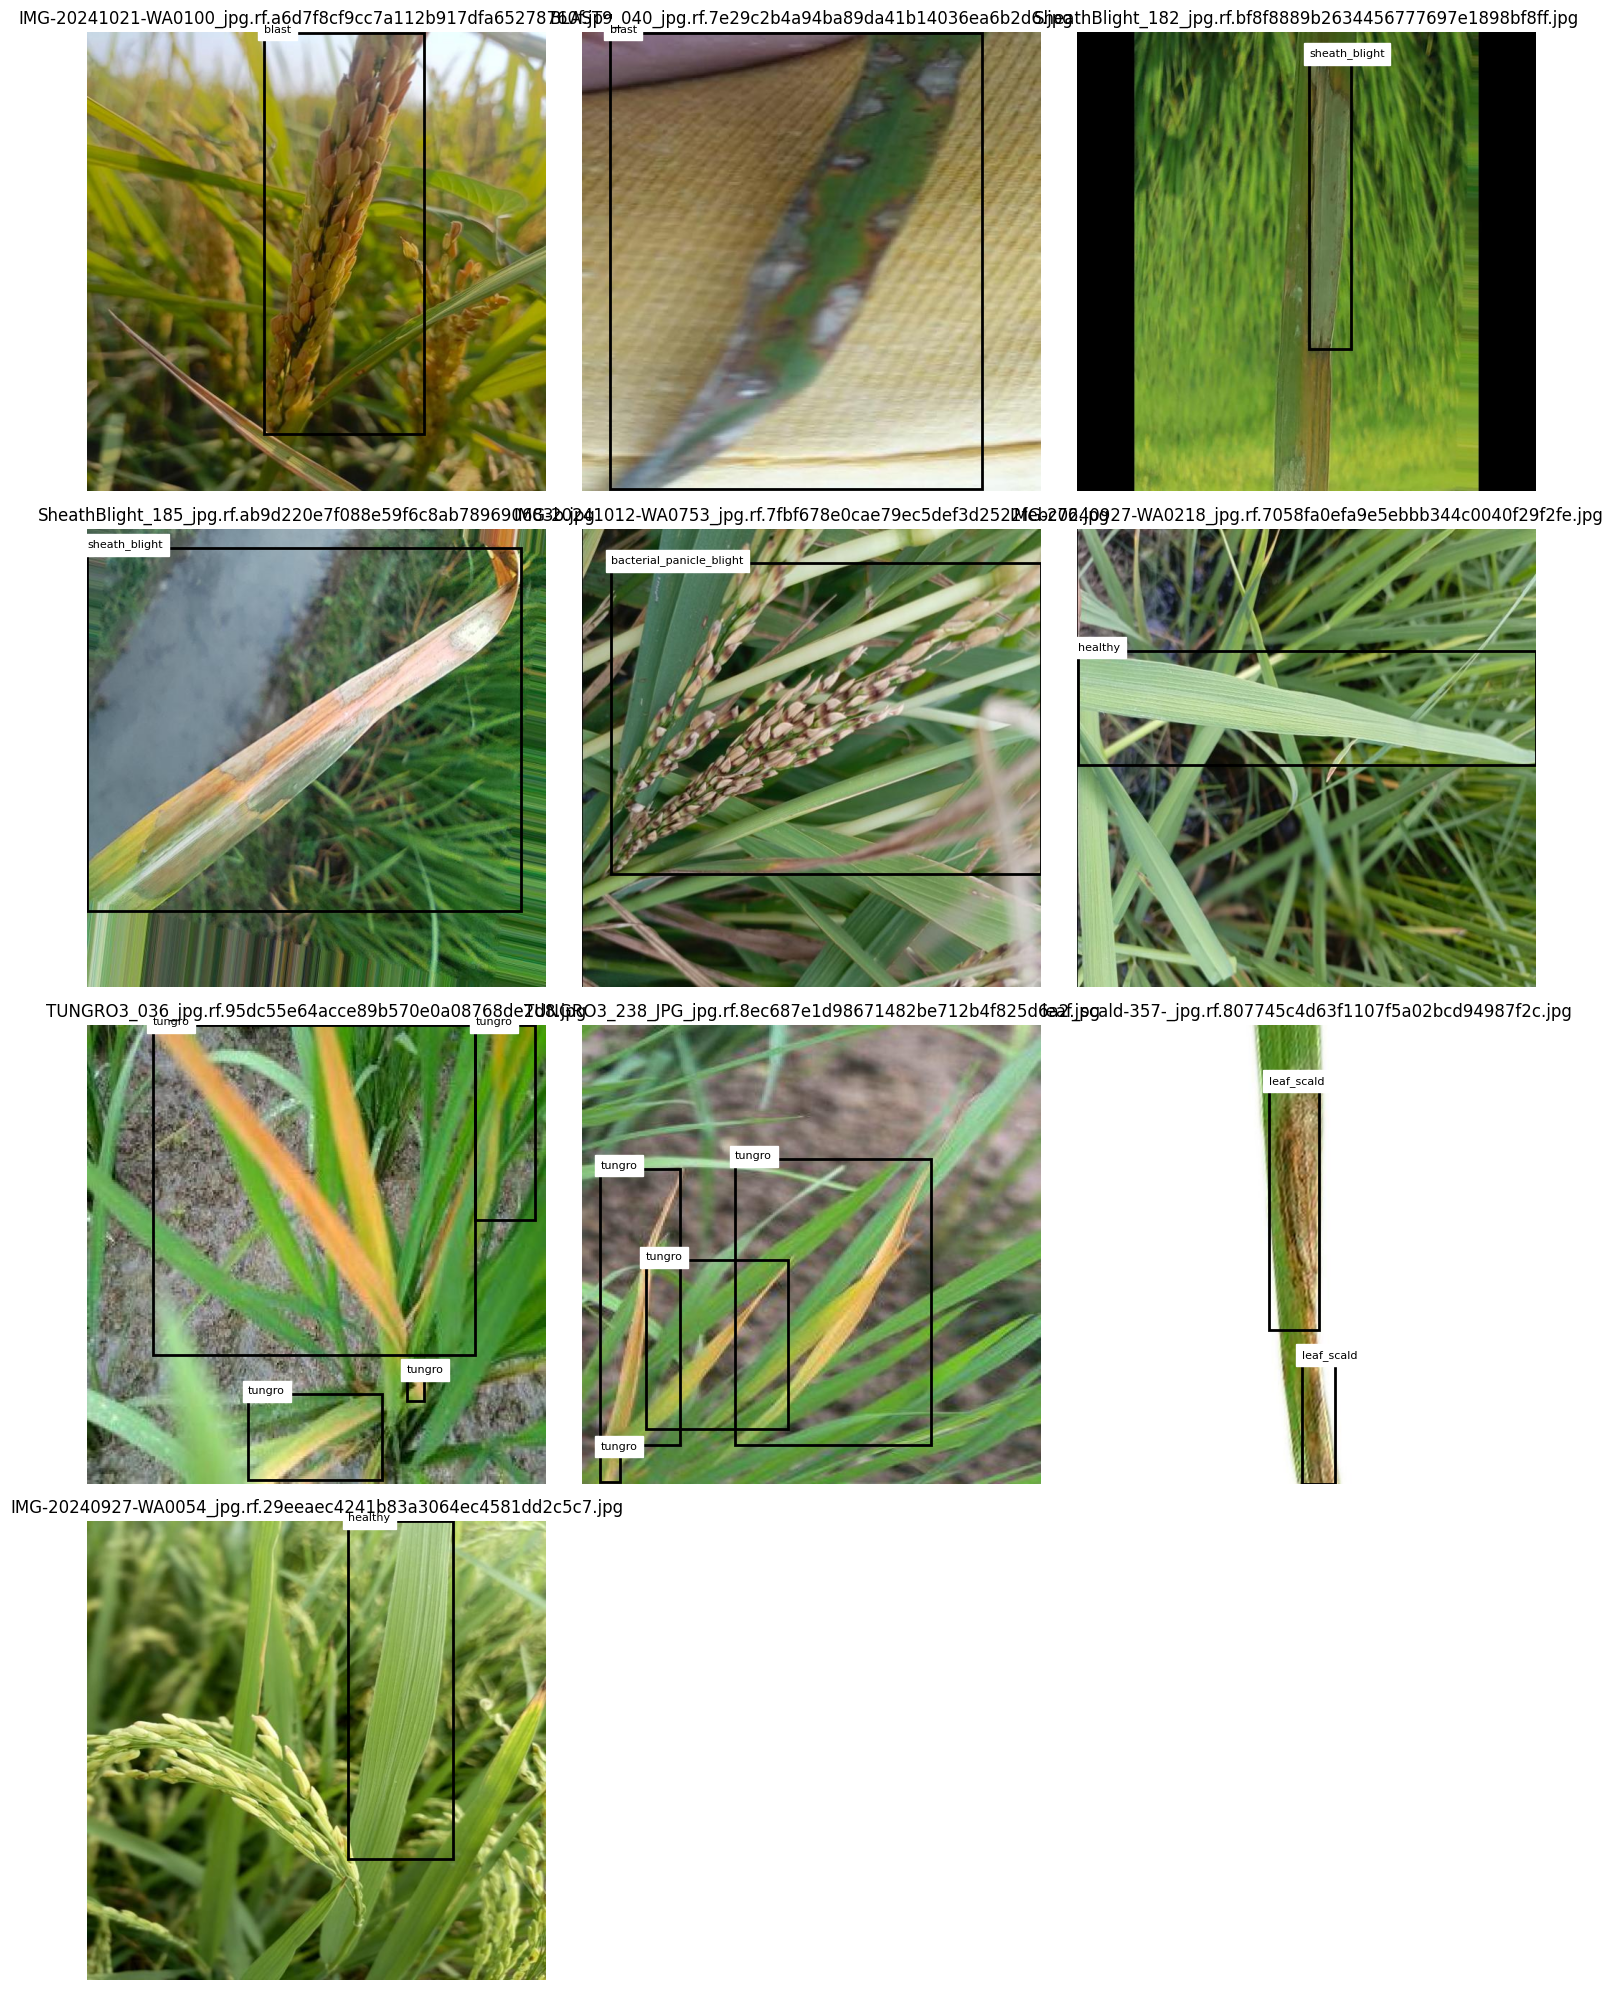

In [25]:
visualisasi_sampel(
    YOLO_OUT,
    split="train",
    sample_size=10
)

In [26]:
Hitung_kelas = Counter()

for split in SPLITS:

    labels_dir = (
        YOLO_OUT /
        split /
        "labels"
    )

    for label_path in labels_dir.rglob(
        "*.txt"
    ):

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        for line in lines:

            if not line.strip():
                continue

            class_id = int(
                line.split()[0]
            )

            Hitung_kelas[class_id] += 1

print("Distribusi seluruh dataset:\n")

for class_id, class_name in enumerate(
    KELAS_CANONICAL
):

    print(
        f"{class_id:2d} "
        f"{class_name:<30} "
        f": {Hitung_kelas[class_id]}"
    )

Distribusi seluruh dataset:

 0 bacterial_leaf_blight          : 660
 1 bacterial_panicle_blight       : 600
 2 blast                          : 5631
 3 brown_spot                     : 7311
 4 false_smut                     : 981
 5 healthy                        : 2982
 6 leaf_scald                     : 2047
 7 leaf_roller                    : 943
 8 narrow_brown                   : 333
 9 tungro                         : 3711
10 sheath_blight                  : 2519


In [27]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [28]:
from ultralytics import YOLO

model_yolo26n = YOLO("yolo26n.yaml")

results_yolo26n = model_yolo26n.train(
    data=str(YOLO_OUT / "data.yaml"),

    epochs=100,
    imgsz=640,
    batch=32,
    patience=30,

    pretrained=False,
    seed=SEED,
    momentum=0.937,
    optimizer="MuSGD",
    warmup_epochs=1,
    weight_decay=0.0005,
    cos_lr= True,
    lr0=0.01,
    lrf=0.01,
    mosaic=1.0 ,
    mixup=0.05,
    fliplr=0.5,
    degrees=0,
    shear=0,
    translate=0.1,
    close_mosaic= 10,  
    copy_paste=0.0,
    scale= 0.5,
    box=7.5,
    cls=0.5,
    dfl=1.5,

    project="/kaggle/working/",
    name=" train_yolo_26n",
    exist_ok=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/YOLO_Dataset/data.yaml, degrees=0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/100      7.16G      2.636      4.288    0.04279        106        640: 100% ━━━━━━━━━━━━ 315/315 3.2it/s 1:38
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 2.7it/s 12.4s
                   all       2093       4887      0.232      0.124     0.0296    0.00802

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/100      7.16G      2.283      3.837    0.03344         89        640: 100% ━━━━━━━━━━━━ 315/315 3.2it/s 1:37
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 2.7it/s 12.0s
                   all       2093       4887      0.317      0.218      0.103     0.0367

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/100      7.16G       2.19       3.54    0.03127         70        640: 100% ━━━━━━━━━━━━ 315/315 3.2it/s 1:38
                 Class     Images  Instances      Box(

In [29]:
model_yolo26n_2 = YOLO("/kaggle/working/ train_yolo_26n/weights/best.pt")
results_yolo26n_2 =model_yolo26n_2.train(
    data=str(YOLO_OUT / "data.yaml"),
    imgsz=640,
    epochs=60,
    seed=SEED,
    batch=32,
    optimizer="MuSGD",
    lr0=0.005,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=1,
    cos_lr=True,
    patience=20,
    box=5.63,
    cls=0.56,
    dfl=9.04,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.075,
    scale=0.562,
    fliplr=0.5,
    degrees=0.0,
    shear=0.0,
    translate=0.01,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    bgr=0.0,
    close_mosaic=10,
    project="/kaggle/working/",
    name="finetune_yolo26n",
    exist_ok=True
)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=5.63, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.56, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.075, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/YOLO_Dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=9.04, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=/kaggle/working/ train_yolo_26n/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

In [30]:
best_model= YOLO("/kaggle/working/finetune_yolo26n/weights/best.pt")

In [31]:
metrics = best_model.val(
    data=str(YOLO_OUT / "data.yaml"),
    split="val",
    imgsz=640
)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1090.3±622.8 MB/s, size: 37.5 KB)
val: Scanning /kaggle/working/YOLO_Dataset/valid/labels.cache... 2093 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2093/2093 877.9Mit/s 0.0s
val: /kaggle/working/YOLO_Dataset/valid/images/rtf_38_jpg.rf.2131d44635500a76448ff693d761baa1.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 131/131 7.8it/s 16.8s
                   all       2093       4887      0.742      0.686      0.708       0.46
 bacterial_leaf_blight         69        125      0.542       0.48      0.468      0.208
bacterial_panicle_blight         45         45      0.764      0.862      0.841      0.627
                 blast        382        947      0.707      0.497      0.55

In [32]:
print("mAP50 :", metrics.box.map50)
print("mAP50-95 :", metrics.box.map)

mAP50 : 0.707859755207677
mAP50-95 : 0.46024551948648995


In [33]:
precision = metrics.box.mp
recall = metrics.box.mr

if precision + recall > 0:
    f1 = (
        2 * precision * recall
        / (precision + recall)
    )
else:
    f1 = 0

print("F1-score :", f1)

F1-score : 0.7130392089818797


In [34]:
valid_images_dir = (YOLO_OUT /"valid" /"images")

sample_images = random.sample(
     [   
        p for p in valid_images_dir.rglob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ],
    5
)

In [35]:
predictions = best_model.predict(
    source=[
        str(p)
        for p in sample_images
    ],
    imgsz=640,
    conf=0.25,
    save=True
)


0: 640x640 1 blast, 5.2ms
1: 640x640 1 brown_spot, 5.2ms
2: 640x640 1 healthy, 5.2ms
3: 640x640 4 brown_spots, 5.2ms
4: 640x640 1 tungro, 5.2ms
Speed: 1.1ms preprocess, 5.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


In [36]:
final_metrics = best_model.val(
    data=str(YOLO_OUT/"data.yaml"),
    split="test",
    imgsz=640
)

print(
    "Test mAP50 :",
    final_metrics.box.map50
)

print(
    "Test mAP50-95 :",
    final_metrics.box.map
)

test_precision = final_metrics.box.mp
test_recall = final_metrics.box.mr

if test_precision + test_recall > 0:

    test_f1 = (
        2 * test_precision * test_recall
        / (test_precision + test_recall)
    )

else:
    test_f1 = 0

print(
    "Test Precision :",
    test_precision
)

print(
    "Test Recall    :",
    test_recall
)

print(
    "Test F1-score  :",
    test_f1
)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1603.4±903.1 MB/s, size: 54.9 KB)
val: Scanning /kaggle/working/YOLO_Dataset/test/labels... 1054 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1054/1054 1.3Kit/s 0.8s
val: /kaggle/working/YOLO_Dataset/test/images/rtf_43_jpg.rf.8f5cea06bb2ce124569df84dec45f100.jpg: 1 duplicate labels removed
val: New cache created: /kaggle/working/YOLO_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 7.4it/s 8.9s
                   all       1054       2669      0.746       0.66      0.681      0.454
 bacterial_leaf_blight         29         59      0.457      0.356      0.326       0.17
bacterial_panicle_blight         27         27        0.8      0.852      0.883      0.578
                 b

In [37]:
import shutil

shutil.make_archive("yolo26n_best_weights", 'zip', "/kaggle/working/finetune_yolo26n/weights")
print("File zip berhasil dibuat!")

File zip berhasil dibuat!
